# Model B: SVM con Preprocesamiento Clásico
 
 > **Dataset:** Stroke Prediction Dataset (Kaggle)  
 > **Fuente:** https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset  
 > **Algoritmo principal:** Support Vector Machine (SVM, sklearn SVC)  
 > **Preprocesamiento:** imputación de valores faltantes (mediana para numéricos, moda para categóricos), escalado estándar para numéricos, one-hot encoding para categóricos  
 > **Búsqueda de hiperparámetros:** Optuna

# Conclusiones de este modelo

- El modelo muestra **recall alto para la clase positiva (stroke)** y **precisión baja**, por lo que actúa como detector sensible con muchos falsos positivos.
- **Average Precision (AP = 0.2186)** está claramente por encima de la prevalencia de la clase positiva en test (~0.049), indicando buen poder de ranking en escenario desbalanceado.
- **ROC-AUC = 0.8617** confirma buena capacidad de separación global entre clases.
- Para un enfoque **ensemble-first**, este perfil puede aportar diversidad útil (especialmente en soft voting/stacking), aunque no sea el mejor modelo standalone a umbral fijo.

---

In [7]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

import optuna
from optuna.samplers import TPESampler

from src.data_loader import load_dataset, get_train_test_split
from src.evaluation import plot_full_evaluation
from src.model_registry import save_model

optuna.logging.set_verbosity(optuna.logging.WARNING)

%matplotlib inline

## 1. Load Data

In [8]:
df = load_dataset()
X_train, X_test, y_train, y_test = get_train_test_split(df)

# Remove identifier feature to avoid learning spurious record-specific patterns.
X_train = X_train.drop(columns=["id"], errors="ignore")
X_test = X_test.drop(columns=["id"], errors="ignore")

Loaded dataset: 5110 rows, 12 columns.
Split: train=4088 rows, test=1022 rows (test_size=0.2, seed=13)


## 2. Define Pipeline

Preprocess numeric and categorical columns separately, then train an SVM classifier.

In [9]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

base_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "clf",
            SVC(
                probability=True,
                class_weight="balanced",
                random_state=13,
            ),
        ),
    ]
)

base_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## 3. Hyperparameter Search (Optuna, objective = Average Precision)

In [10]:
# Hyperparameter tuning uses cross-validation on the training set only.
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=13)


def build_pipeline_from_trial(trial: optuna.trial.Trial) -> Pipeline:
    kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])
    c_value = trial.suggest_float("C", 1e-3, 1e2, log=True)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    svc_params = {
        "C": c_value,
        "kernel": kernel,
        "probability": True,
        "class_weight": class_weight,
        "random_state": 13,
    }

    if kernel == "rbf":
        svc_params["gamma"] = trial.suggest_float("gamma", 1e-4, 1e0, log=True)

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("clf", SVC(**svc_params)),
        ]
    )


def objective(trial: optuna.trial.Trial) -> float:
    model = build_pipeline_from_trial(trial)
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="average_precision",
        n_jobs=-1,
    )
    return float(np.mean(scores))


study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=13),
)
study.optimize(objective, n_trials=100)

best_params = study.best_params
best_cv_score = study.best_value

print(f"Best CV Average Precision: {best_cv_score:.4f}")
print(f"Best params: {best_params}")

best_trial = study.best_trial
best_model = build_pipeline_from_trial(best_trial)
best_model.fit(X_train, y_train)

X_train shape: (4088, 10)
y_train shape: (4088,)
X_test shape: (1022, 10)
y_test shape: (1022,)
Best CV Average Precision: 0.2041
Best params: {'kernel': 'rbf', 'C': 2.151886563007024, 'class_weight': 'balanced', 'gamma': 0.007723332118850141}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## 4. Evaluate Final Model on Test (No Threshold Sweep)

=== Model B - SVM ===
              precision    recall  f1-score   support

           0       0.99      0.72      0.84       972
           1       0.14      0.88      0.24        50

    accuracy                           0.73      1022
   macro avg       0.57      0.80      0.54      1022
weighted avg       0.95      0.73      0.81      1022



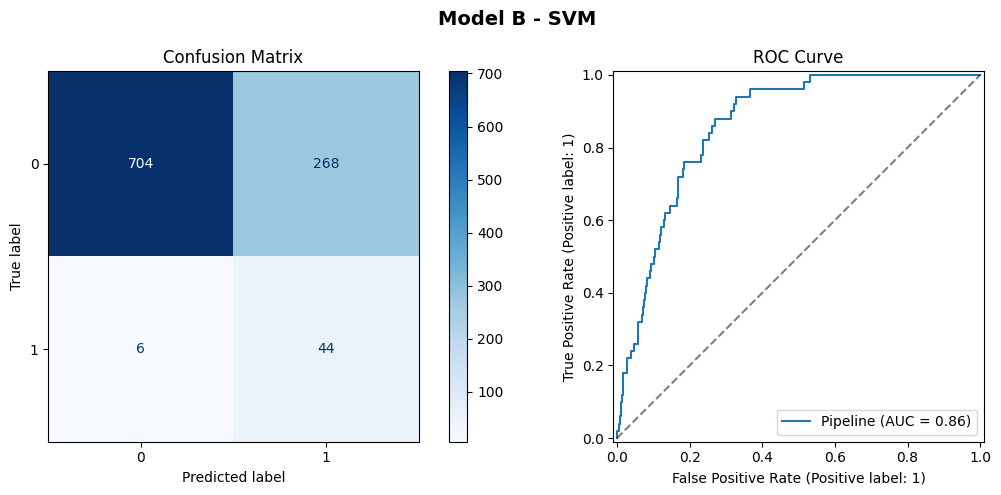

Test Average Precision: 0.2186
Test ROC-AUC: 0.8617


In [11]:
metrics_default = plot_full_evaluation(
    best_model,
    X_test,
    y_test,
    model_name="Model B - SVM",
)

y_proba_test = best_model.predict_proba(X_test)[:, 1]

test_average_precision = average_precision_score(y_test, y_proba_test)
test_roc_auc = roc_auc_score(y_test, y_proba_test)

print(f"Test Average Precision: {test_average_precision:.4f}")
print(f"Test ROC-AUC: {test_roc_auc:.4f}")

## 5. Save Model

In [12]:
save_model(
    model=best_model,
    name="model_B",
    params=best_params,
    cv_score=best_cv_score,
    extra_metadata={
        "optimization_metric": "average_precision",
        "n_trials": 100,
    },
)

Model saved to /home/mmw/Documents/MIA/ml/AdM_TP/artifacts/model_B/model.joblib
Params saved to /home/mmw/Documents/MIA/ml/AdM_TP/artifacts/model_B/params.yaml


PosixPath('/home/mmw/Documents/MIA/ml/AdM_TP/artifacts/model_B')